In [11]:
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
# Carregar e limpar
df = pd.read_csv('dados_2025.csv')
df['valorTransacao'] = pd.to_numeric(
    df['valorTransacao'].str.replace('.','').str.replace(',','.').str.replace('- ','-')
)
df['dataTransacao'] = pd.to_datetime(
    df['dataTransacao'].str.replace('Sem informação', ''), dayfirst=True
)
df = df[df['dataTransacao'].dt.year == 2025]
df = df.drop_duplicates()
df = df.dropna(subset=['dataTransacao'])

Não São incluídos dados sigilosos, pois não contém a data de transação

In [13]:
# Agregar por mês e ano
df['mes_ano'] = df['dataTransacao'].dt.to_period('M')
gasto_mensal = df.groupby('mes_ano')['valorTransacao'].sum()

#pivot_semana
dias = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sáb', 6:'Dom'}
df['dia_semana'] = df['dataTransacao'].dt.dayofweek.map(dias)

ordem_dias = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
pivot = df.pivot_table(
    values='valorTransacao',
    index='unidadeGestora.orgaoMaximo.nome',
    columns='dia_semana',
    aggfunc='sum',
    fill_value=0
)[ordem_dias]

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

In [14]:
#Ignorar orgãos que gastaram menos que 100k
pivot = pivot[pivot.sum(axis=1) >= 0.1*1e6]

In [15]:
# alterar os nomes dos orgãos
def shorten(name):
    replacements = {
        'Ministério': 'Min.',
        'Presidência da República': 'Presidência',
        'Banco Central do Brasil - Orçamento Fiscal e Seguridade Social': 'Banco Central',
    }
    for k, v in replacements.items():
        name = name.replace(k, v)
    return name[:55]

In [16]:
#porcentagem
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

In [17]:
#formatar valor nos gráficos
def formatar_moeda(x,pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}Bi'
    elif x >= 1e6:
        return f'{x/1e6:.0f}Mi'
    elif x >= 1e3:
        return f'{x/1e3:.0f}k'
    else:
        return '' 


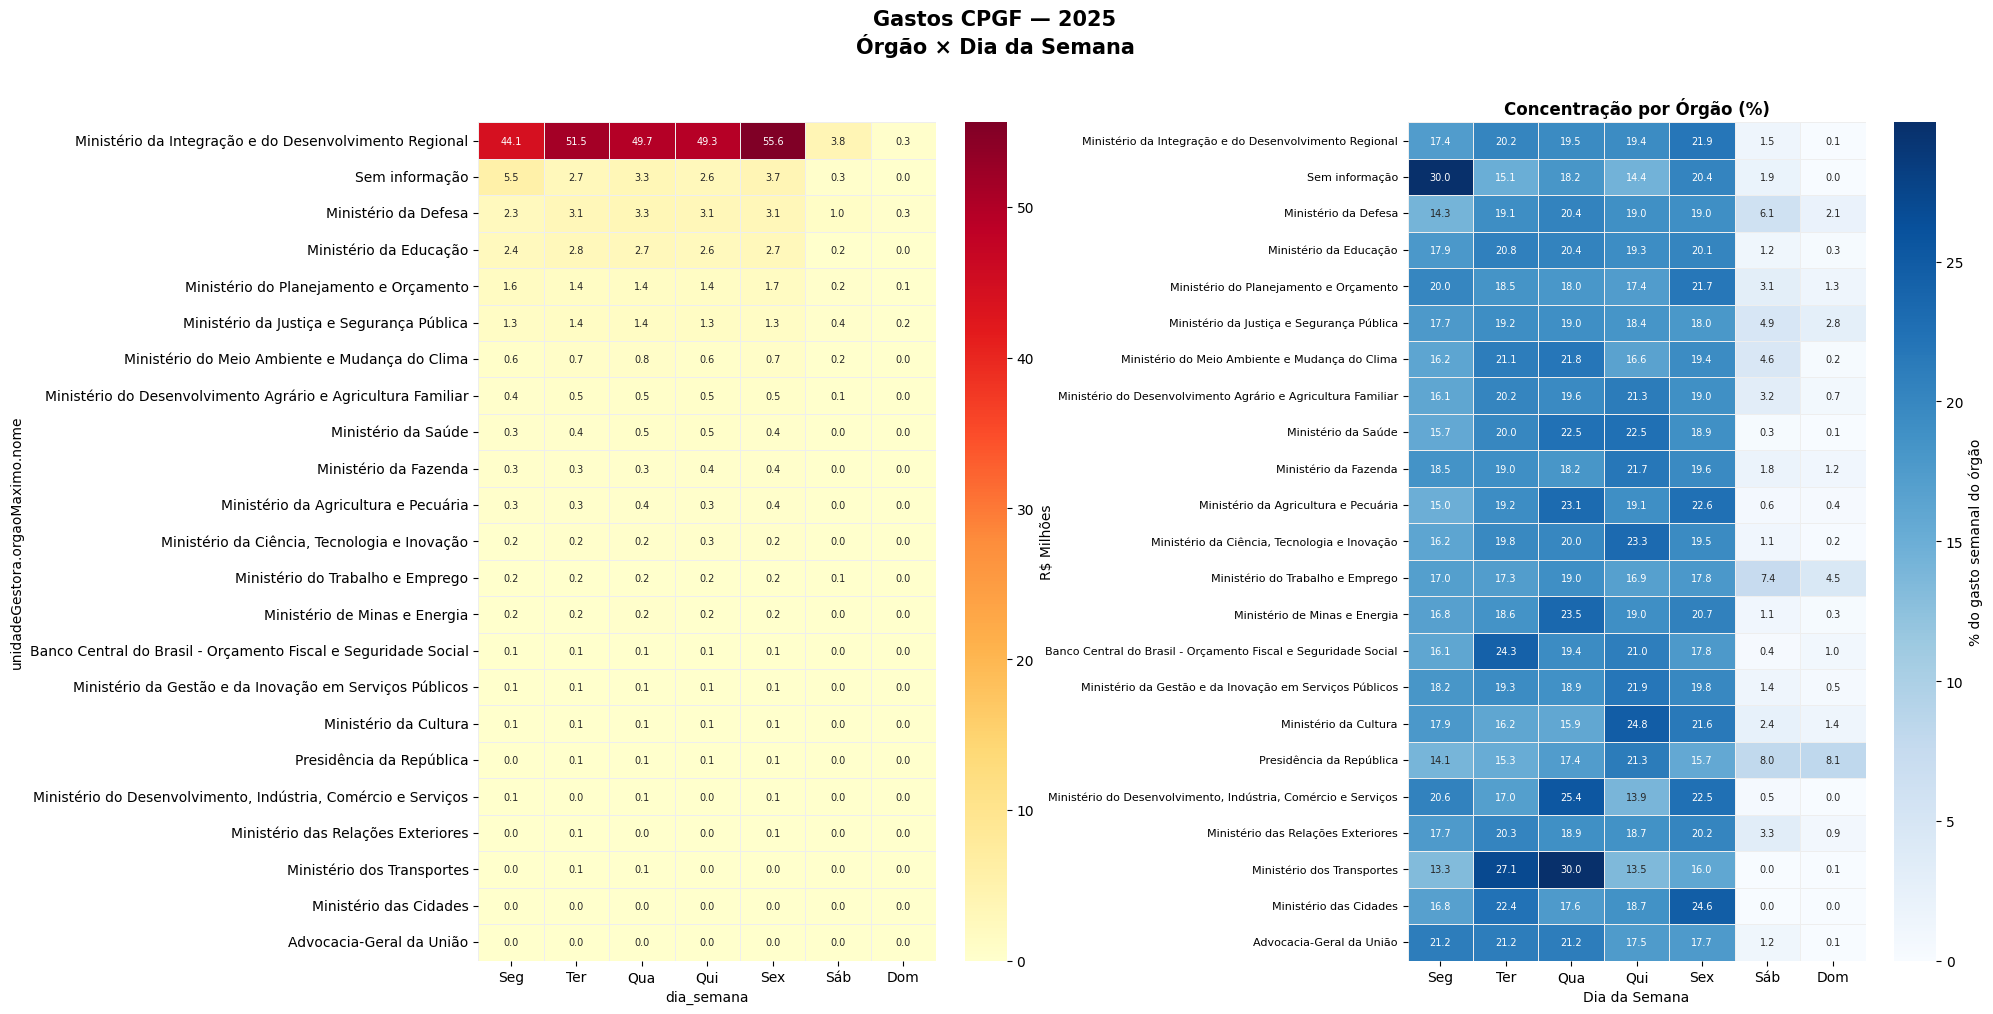

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
plt.suptitle('Gastos CPGF — 2025\nÓrgão × Dia da Semana', fontsize=15, fontweight='bold', y=1.01)

# Heatmap 1: Valor absoluto
sns.heatmap(
    pivot / 1e6,
    ax=axes[0],
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#eee',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'R$ Milhões'}
)
plt.title('Valor Total (R$ Mi)', fontsize=12, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('')
plt.tick_params(axis='y', labelsize=8)

# Heatmap 2: % por órgão
sns.heatmap(
    pivot_pct,
    ax=axes[1],
    cmap='Blues',
    linewidths=0.4,
    linecolor='#eee',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cbar_kws={'label': '% do gasto semanal do órgão'}
)
plt.title('Concentração por Órgão (%)', fontsize=12, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('')
plt.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('assets/heatmap_orgao_diasemana.png')
plt.show()

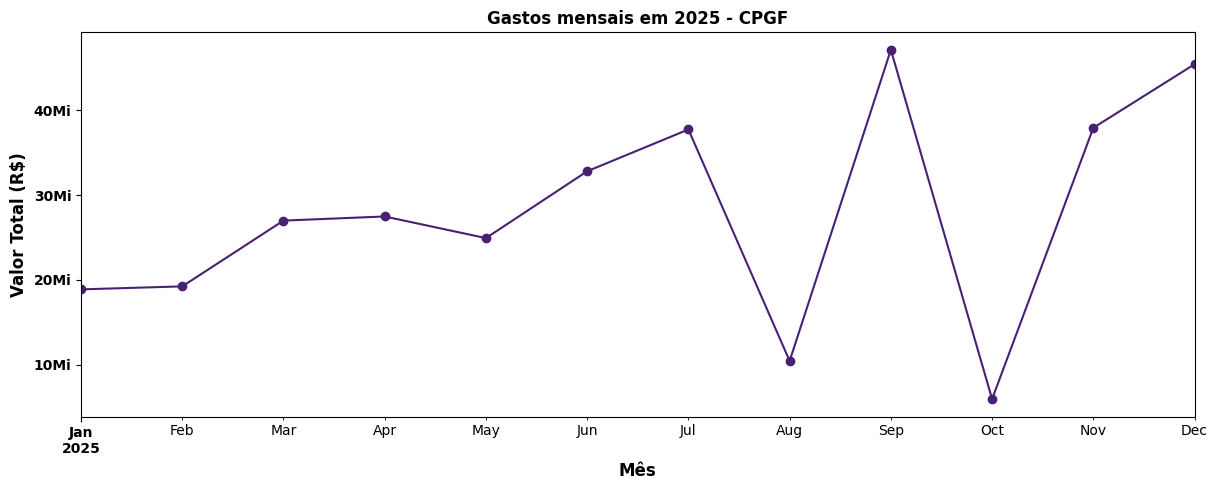

In [19]:
gasto_mensal.plot(color= '#482173',kind='line', marker='o', figsize=(12, 5))
plt.title("Gastos mensais em 2025 - CPGF",fontsize=12, fontweight='bold')
plt.ylabel("Valor Total (R$)",fontsize=12, fontweight='bold')
plt.xlabel("Mês",fontsize=12, fontweight='bold')
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))
plt.savefig('assets/gastos_mes.png')
plt.show()